# 프로젝트 : 더 멋진 번역기 만들기

**Transformer를 직접 구현**해서 한국어 -> 영어 번역기를 만들어보는 프로젝트다.

이전 seq2seq 프로젝트에서는 mecab으로 형태소 분석을 해서 토큰화를 했었는데, 이번에는 SentencePiece를 써서 서브워드 단위로 토큰화를 한다는 게 가장 큰 차이점이다. 그리고 저번엔 LSTM 기반의 Encoder-Decoder를 썼다면 이번엔 논문(Attention is All You Need)에서 나온 구조를 그대로 따라서 Multi-Head Attention, Positional Encoding, Layer Normalization 같은 걸 하나하나 다 직접 구현해본다.

## Step 1. 라이브러리 설치 및 버전을 확인

`sentencepiece`는 기본 환경에 설치되어 있지 않은 경우가 많아서 먼저 설치해준다. 그 다음 사용할 라이브러리 버전을 찍어본다. Transformer 계열은 torch 버전에 따라 미묘하게 동작이 달라질 때가 있어서(특히 masked_fill이나 LayerNorm eps 처리 관련) 처음에 버전을 확인해두는 습관을 들이는 게 좋은것 같다.

In [1]:
!pip install -q sentencepiece

In [31]:
!pip install -q koreanize-matplotlib

import koreanize_matplotlib  # import만 해도 matplotlib 폰트가 자동으로 한글 폰트로 설정됨

In [2]:
import torch
import numpy as np
import matplotlib
import sentencepiece as spm

print(torch.__version__)
print(np.__version__)
print(matplotlib.__version__)
print(spm.__version__)

2.7.1+cu118
2.2.6
3.10.3
0.2.2


## Step 2. 데이터 다운로드

공개된 한영 병렬 코퍼스(`korean-english-park.train`)를 사용한다. 뉴스 기사 기반 병렬 코퍼스라서 문어체 위주이고, 문장 길이도 저번 seq2seq 때 썼던 데이터보다 훨씬 다양한 편이다.


In [3]:
!mkdir -p ~/work/transformer/data

In [4]:
!wget -q https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz -O ~/work/transformer/data/korean-english-park.train.tar.gz
!gzip -d ~/work/transformer/data/korean-english-park.train.tar.gz
!tar -xvf ~/work/transformer/data/korean-english-park.train.tar -C ~/work/transformer/data

korean-english-park.train.en
korean-english-park.train.ko


## Step 3. 데이터 정제 및 토큰화

### 3-1. 중복 제거

데이터형이 중복을 허용하지 않는다는 `set`의 특징을 활용해서 중복된 데이터를 제거한다. 데이터의 병렬 쌍이 흐트러지지 않도록 `kor \t eng` 형태로 묶은 다음에 set에 넣고 다시 풀어주는 방식으로 짰다. (그냥 kor, eng 각각 따로 set 처리하면 짝이 깨져버리니까 반드시 pair 단위로 묶어야 한다는 걸 처음에 실수하고 나서 깨달았다.)

In [5]:
import os

def clean_corpus(kor_path, eng_path):
    with open(kor_path, "r") as f:
        kor = f.read().splitlines()
    with open(eng_path, "r") as f:
        eng = f.read().splitlines()
    assert len(kor) == len(eng)

    # kor-eng를 짝지어서 set에 넣어야 병렬 쌍이 안 깨진다.
    cleaned_corpus = list(set(["\t".join([k, e]) for k, e in zip(kor, eng)]))
    return cleaned_corpus

data_dir = os.path.join(os.getenv("HOME"), "work/transformer/data/")
kor_path = data_dir + "korean-english-park.train.ko"
eng_path = data_dir + "korean-english-park.train.en"

cleaned_corpus = clean_corpus(kor_path, eng_path)
print("정제 전:", len(open(kor_path).read().splitlines()))
print("정제 후(중복 제거):", len(cleaned_corpus))
print(cleaned_corpus[0])

정제 전: 94123
정제 후(중복 제거): 78968
코레아는 “그러나 확인 결과 콜롬비아 폭격기들은 잠옷 차림으로 잠을 자고 있던 좌익게릴라들을 공격한 것으로 드러났다”며 “콜롬비아 정부군은 또 에콰도르 영토를 무단으로 침입했다”고 주장했다.	But Correa said his forces investigated Uribe's claims and discovered that the Colombian planes attacked the guerrillas as they slept in a camp 2 km ( 1.2 mi) inside Ecuador. "Of course Ecuadoran air space was invaded," he said.


### 3-2. 문장 정제 함수

정제 함수는 아래 조건을 만족하도록 만든다.
- 모든 입력을 소문자로 변환한다.
- 알파벳, 문장부호, 한글만 남기고 모두 제거한다.
- 문장부호 양옆에 공백을 추가한다. (`?.!,`를 하나의 독립된 토큰처럼 다루기 위해서)
- 문장 앞뒤의 불필요한 공백을 제거한다.

In [6]:
import re

def preprocess_sentence(sentence):
    sentence = sentence.lower()
    # 알파벳, 한글, 지정된 문장부호(? . ! ,)만 남기고 나머지는 공백으로 치환
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    # 문장부호 앞뒤로 공백을 넣어서 하나의 토큰처럼 분리되게 함
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    # 공백이 여러 개 겹치면 하나로 합침
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = sentence.strip()
    return sentence

# 테스트
print(preprocess_sentence("  오바마는 미국의 첫 흑인 대통령이다!!  "))
print(preprocess_sentence("Obama is the first African-American president of the U.S.!"))

오바마는 미국의 첫 흑인 대통령이다 ! !
obama is the first african american president of the u . s . !


### 3-3. SentencePiece 토크나이저 학습

한글 말뭉치 `kor_corpus`와 영문 말뭉치 `eng_corpus`를 각각 분리한 후 정제하고, SentencePiece로 토큰화를 진행한다.

- 참고: [google/sentencepiece](https://github.com/google/sentencepiece)
- 단어 사전은 매개변수로 원하는 크기를 정의할 수 있게 한다. (기본값 20,000)
- 학습 후 저장된 `model` 파일을 `SentencePieceProcessor()`로 로드해서 반환한다.
- 특수 토큰 인덱스는 `<PAD>`: 0, `<BOS>`: 1, `<EOS>`: 2, `<UNK>`: 3으로 통일한다.
- `en_tokenizer`는 타겟(영어) 문장의 시작/끝에 `<BOS>`, `<EOS>` 토큰이 자동으로 붙도록 옵션을 켜준다. (디코더 입력/정답에 시작·끝 토큰이 필요하기 때문)

> 참고: sentencepiece 버전에 따라 `set_encode_extra_options`가 없는 구버전/신버전 차이가 있어서, 둘 다 대응되도록 try/except로 처리했다.

In [7]:
def generate_tokenizer(corpus,
                        vocab_size,
                        lang="ko",
                        pad_id=0,
                        bos_id=1,
                        eos_id=2,
                        unk_id=3):
    file = "./%s_corpus.txt" % lang
    model = "%s_spm" % lang

    with open(file, "w") as f:
        for row in corpus:
            f.write(str(row) + "\n")

    spm.SentencePieceTrainer.Train(
        "--input=%s --model_prefix=%s --vocab_size=%d" % (file, model, vocab_size) +
        " --pad_id=%d --bos_id=%d --eos_id=%d --unk_id=%d" % (pad_id, bos_id, eos_id, unk_id)
    )

    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load("%s.model" % model)
    return tokenizer

SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

eng_corpus = []
kor_corpus = []

for pair in cleaned_corpus:
    k, e = pair.split("\t")
    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")

# en_tokenizer는 타겟 입력이 문장의 시작/끝 토큰을 포함하도록 설정
try:
    en_tokenizer.set_encode_extra_options("bos:eos")
except AttributeError:
    # 최신 sentencepiece(0.2.x)는 이 메서드가 없어서 encode 호출 시 add_bos/add_eos 옵션으로 대체
    _orig_encode_as_ids = en_tokenizer.encode_as_ids
    en_tokenizer.encode_as_ids = lambda s: _orig_encode_as_ids(s, add_bos=True, add_eos=True)

print(ko_tokenizer.encode_as_pieces(kor_corpus[0]))
print(en_tokenizer.encode_as_ids(eng_corpus[0]))

I0000 00:00:1783877103.482340     710 sentencepiece_trainer.cc:227] Running command: --input=./ko_corpus.txt --model_prefix=ko_spm --vocab_size=20000 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
I0000 00:00:1783877103.483717     710 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: ./ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file

['▁코레아', '는', '▁그러나', '▁확인', '▁결과', '▁콜롬비아', '▁폭격기', '들은', '▁잠', '옷', '▁차림으로', '▁잠을', '▁자', '고', '▁있던', '▁좌익', '게', '릴', '라', '들을', '▁공격한', '▁것으로', '▁드러났다', '▁며', '▁콜롬비아', '▁정부군은', '▁또', '▁에콰도르', '▁영토', '를', '▁무', '단', '으로', '▁침입', '했다', '▁고', '▁주장했다', '▁.']
[1, 33, 10439, 13, 28, 227, 4088, 5448, 12, 1076, 11, 1210, 15, 4, 2391, 2633, 1406, 4, 4950, 23, 37, 11727, 10, 9, 970, 1698, 5, 4319, 626, 4813, 5, 8, 1111, 14559, 330, 375, 18, 11925, 6, 24, 13, 5, 2]


### 3-4. 학습용 텐서 만들기

토크나이저로 토큰의 길이가 50 이하인 데이터만 선별해서 `src_corpus`와 `tgt_corpus`를 각각 구축하고, 텐서 `enc_train`과 `dec_train`으로 변환한다.

(주의: 모든 데이터를 사용할 경우 학습에 공정히 오랜 시간이 걸린다고 되어 있어서, 50 토큰 이하 필터링이 데이터 양을 꽤 줄여주는 역할도 한다.)

In [8]:
import torch
from tqdm import tqdm

src_corpus = []
tgt_corpus = []

assert len(kor_corpus) == len(eng_corpus)

# 토큰의 길이가 50 이하인 문장만 사용한다.
for idx in tqdm(range(len(kor_corpus))):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx])

    if len(src_tokens) <= 50 and len(tgt_tokens) <= 50:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

def pad_sequences(sequences, padding_value=0):
    return torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=padding_value)

# 패딩처리를 완료하여 학습용 데이터를 완성한다.
enc_train = pad_sequences(src_corpus, padding_value=0)
dec_train = pad_sequences(tgt_corpus, padding_value=0)

print(enc_train.shape, dec_train.shape)

100%|██████████| 78968/78968 [00:05<00:00, 14139.85it/s]


torch.Size([75567, 50]) torch.Size([75567, 50])


## Step 4. 모델 설계

오늘 배운 내용을 활용해서 Transformer 모델을 설계한다. 논문 구조(Positional Encoding -> Multi-Head Attention -> Position-wise FFN, Pre-LN 방식)를 그대로 따라 구현했다.

### 4-1. Positional Encoding

RNN과 달리 Transformer는 입력을 순서대로 처리하지 않기 때문에, 위치 정보를 따로 넣어줘야 한다. sin/cos 함수를 이용한 sinusoidal encoding을 그대로 구현했다.

In [9]:
import math

def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])  # 짝수 인덱스는 sin
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])  # 홀수 인덱스는 cos

    return sinusoid_table

### 4-2. Multi-Head Attention

Q, K, V를 각각 linear projection한 뒤 head 수만큼 쪼개서 attention을 병렬로 계산하고 다시 합치는 구조다.

`scaled_dot_product_attention`에서 mask 처리할 때 주의할 점이 있는데, 아래 `generate_masks`에서 만드는 mask는 **1이 "가려야 할 위치"(패딩이거나 미래 토큰)** 를 의미하도록 설계했다. 그래서 `masked_fill`도 `mask == 1`인 자리를 `-1e9`로 채워야 방향이 맞다. (처음에 `mask == 0` 으로 잘못 짜서 디버깅하다가 발견한 부분 — mask를 만드는 함수 쪽과 사용하는 함수 쪽의 컨벤션을 반드시 맞춰야 한다는 걸 배웠다.)

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = K.shape[-1]
        QK = torch.matmul(Q, K.transpose(-2, -1))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            # mask == 1 인 자리(패딩 또는 causal하게 가려야 하는 미래 토큰)를 -1e9로 채워서
            # softmax를 취했을 때 확률이 거의 0이 되도록 만든다.
            scaled_qk = scaled_qk.masked_fill(mask == 1, float('-1e9'))

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)

        return out, attentions

    def split_heads(self, x):
        bsz, seq_len, d_model = x.shape
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        bsz, num_heads, seq_len, depth = x.shape
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

### 4-3. Position-wise Feed Forward Network

각 위치마다 독립적으로 적용되는 2층짜리 FC 레이어다. 중간에 ReLU를 거쳐서 차원을 늘렸다가 다시 줄인다.

In [11]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

### 4-4. Encoder Layer / Decoder Layer

Pre-LN 구조를 사용한다. (LayerNorm -> Sub-layer -> Dropout -> Residual 순서) Post-LN보다 학습이 안정적이라고 배웠다.

Decoder Layer는 Self-Attention(causal mask), Encoder-Decoder Attention(padding mask), FFN 세 개의 sub-layer로 이루어진다.

In [12]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """ Multi-Head Attention """
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        """ Position-Wise Feed Forward Network """
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn

In [13]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        """ Masked Multi-Head Attention (Self-Attention, causal + padding mask) """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, dec_mask)
        out = self.dropout(out)
        out += residual

        """ Multi-Head Attention (Encoder-Decoder Attention, padding mask) """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, dec_enc_mask)
        out = self.dropout(out)
        out += residual

        """ Position-Wise Feed Forward Network """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

### 4-5. Encoder / Decoder 스택

`n_layers` 만큼 레이어를 쌓는다. Pre-LN 구조에서는 각 레이어 앞에서 정규화를 하기 때문에, 레이어를 여러 겹 쌓고 나면 residual이 계속 누적되면서 값의 스케일이 계속 커지는 문제가 있다. 그래서 스택을 다 통과한 뒤 **마지막에 한 번 더 LayerNorm을 적용**해줘야 출력이 안정적인 스케일로 유지된다.

(처음에 이 final norm을 빼고 돌렸더니 loss가 수백~수천 단위로 튀는 걸 보고 원인을 찾다가 알게 됐다. Pre-LN Transformer는 마지막 final norm이 필수라는 걸 직접 겪어보니 확실히 이해가 됐다.)

In [14]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        # Pre-LN 구조라서 스택을 다 지나고 나면 값이 누적되어 커지므로, 마지막에 한 번 더 정규화한다.
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask):
        out = x
        enc_attns = []

        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        out = self.final_norm(out)
        return out, enc_attns

In [15]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        out = x

        dec_attns = []
        dec_enc_attns = []

        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](
                out, enc_out, dec_enc_mask, dec_mask
            )
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        out = self.final_norm(out)
        return out, dec_attns, dec_enc_attns

### 4-6. Transformer 전체 모델

Encoder/Decoder를 합치고, embedding + positional encoding까지 붙여서 전체 모델을 완성한다.

`shared=True`일 때는 디코더의 output projection(`fc`)과 디코더 임베딩(`dec_emb`)의 가중치를 공유한다(weight tying). 논문에서 나온 트릭인데, 파라미터 수도 줄고 성능도 좋아진다고 배웠다. weight tying을 쓸 때는 임베딩 값에 `sqrt(d_model)`만큼 스케일을 보정해주는 관행이 있어서 그대로 반영했다.

In [16]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()

        self.d_model = d_model
        self.shared = shared

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        self.pos_encoding = positional_encoding(pos_len, d_model)
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        if shared:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        seq_len = x.shape[1]
        out = emb(x)

        if self.shared:
            out = out * torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32))

        pos_enc = torch.tensor(self.pos_encoding[:seq_len, :], dtype=torch.float32).unsqueeze(0).to(x.device)
        out += pos_enc

        out = self.dropout(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns

### 4-7. 마스크 생성 함수

- `generate_padding_mask`: `<PAD>`(0) 위치를 1로 표시한다.
- `generate_causality_mask`: 디코더가 자기보다 미래 위치를 보지 못하도록 상삼각 부분을 1로 표시한다.
- `generate_masks`: 위 두 개를 조합해서 세 가지 마스크를 만든다.
  - `enc_mask`: 인코더 self-attention용 (소스 패딩만 가림)
  - `dec_mask`: 디코더 self-attention용 (타겟 패딩 + causal, `torch.max`로 조합)
  - `dec_enc_mask`: Cross-Attention(인코더-디코더)용 — **소스 패딩만** 가리면 된다. 디코더가 인코더 출력을 볼 때는 미래/과거 구분이 의미가 없다 (인코더 출력은 이미 문장 전체가 완성된 상태로 나오기 때문). causal한 요소를 여기 섞으면 안 된다.

In [17]:
def generate_padding_mask(seq):
    """ 패딩된 부분(0)을 1로 변환하여 마스크 생성 """
    mask = (seq == 0).float()
    return mask[:, None, None, :]

def generate_causality_mask(src_len, tgt_len):
    """ 미래 정보를 참조하지 않도록 Causal Mask 생성 """
    mask = 1 - torch.cumsum(torch.eye(src_len, tgt_len), dim=0)
    return mask.float()

def generate_masks(src, tgt):
    """ Encoder-Decoder에서 사용할 마스크 생성 """
    enc_mask = generate_padding_mask(src)
    dec_mask = generate_padding_mask(tgt)

    dec_causality_mask = generate_causality_mask(tgt.shape[1], tgt.shape[1])
    dec_mask = torch.max(dec_mask, dec_causality_mask.to(dec_mask.device))

    # Cross-Attention 마스크는 소스 패딩만 가리면 된다 (causality 불필요).
    dec_enc_mask = enc_mask

    return enc_mask, dec_enc_mask, dec_mask

처음엔 여기에 `generate_causality_mask(tgt.shape[1], src.shape[1])`를 만들어서 `enc_mask`랑 `torch.max`로 합친 뒤 `dec_enc_mask`로 썼었다. 그런데 이렇게 하면 디코더가 **N번째 단어를 생성할 때 소스 문장의 앞쪽 N개 토큰밖에 못 보게** 되어버린다 — 첫 번째 단어를 만들 때는 소스의 0번째 토큰 하나만 볼 수 있는 셈이다.

Cross-Attention은 인코더가 이미 문장 전체를 다 읽고 만든 출력을 디코더가 참조하는 거라서, "미래를 보면 안 된다"는 causal 제약 자체가 적용될 이유가 없다. 오직 패딩만 가리면 된다. 그래서 `dec_enc_mask = enc_mask`로 바꿨다.

돌이켜보면 `dec_mask`(디코더 self-attention)에 causal mask를 넣어야 한다는 규칙을, cross-attention에도 그대로 복사해서 적용해버린 실수였다. 세 가지 마스크가 왜 서로 다르게 생겼는지(누가 무엇을 봐도 되고 안 되는지) 하나하나 이유를 따져보지 않고 "마스크는 다 비슷하게 생겼겠지"라고 넘겨짚은 게 원인이었다.

### 4-8. 모델 생성

지시사항대로 **2 Layer**를 가지는 Transformer를 선언한다. (그 외 하이퍼파라미터는 자유롭게 조정 가능하다고 되어 있어서, 논문 원본 세팅에 가깝게 맞췄다.)

In [18]:
N_LAYERS = 2
D_MODEL = 512
N_HEADS = 8
D_FF = 2048
DROPOUT = 0.2

transformer = Transformer(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=DROPOUT,
    shared=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer = transformer.to(device)
print(device)

n_params = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print("학습 파라미터 수:", n_params)

cuda
학습 파라미터 수: 35214880


## Step 5. 훈련하기

앞서 필요한 것들을 모두 정의했기 때문에 이제 훈련만 하면 된다.

### 5-1. Learning Rate Scheduler & Optimizer

논문에서 사용한 것과 동일한 Learning Rate Scheduler(warm-up 후 감소)를 선언하고, 이를 포함하는 Adam Optimizer를 선언한다. (Optimizer의 파라미터 역시 논문과 동일하게 설정한다.)

In [19]:
import math

class LearningRateScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        super(LearningRateScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        # self.last_epoch은 0부터 시작해서 step()마다 1씩 늘어나므로,
        # 실제 "몇 번째 스텝인지"를 구하려면 +1을 해줘야 한다.
        # (+1을 빼먹으면 스케줄이 한 스텝씩 밀려서 계산된다.)
        step = max(1, self.last_epoch + 1)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        lr = (self.d_model ** -0.5) * min(arg1, arg2)
        return [lr for _ in self.base_lrs]

optimizer = torch.optim.Adam(transformer.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
learning_rate = LearningRateScheduler(optimizer, d_model=D_MODEL, warmup_steps=4000)

### 5-2. Loss 함수

Seq2seq 모델에서 사용했던 Loss와 유사하되, **Masking 되지 않은 입력의 개수로 Scaling**하는 과정을 추가한다. (트랜스포머가 모든 입력에 대한 Loss를 한 번에 구하기 때문이다. 패딩 토큰까지 loss에 포함되면 학습이 이상해지니까, 패딩이 아닌 토큰의 개수로 나눠줘서 "실제 토큰 하나당 평균 loss"가 되도록 맞춰준다.)

`label_smoothing=0.1`도 같이 넣었다. 처음엔 안 넣고 돌렸는데, loss는 계속 잘 떨어지는데도 번역 결과가 `the city of the city of the city ...` 처럼 같은 단어를 계속 반복하는 문제가 있었다. 모델이 정답 토큰에 확률을 100%에 가깝게 몰아주도록 과확신하게 학습되면서, 자주 나오는 단어(the, city 같은 것들) 쪽으로 계속 쏠려버리는 게 원인이었다. 논문에서도 label smoothing을 쓰는 이유가 바로 이 과확신을 막아서 일반화 성능을 높이기 위해서라는 걸 다시 찾아보고 나서야 왜 필요한지 이해가 됐다.

In [20]:
loss_object = torch.nn.CrossEntropyLoss(reduction='none', label_smoothing=0.1)

def loss_function(real, pred):
    mask = (real != 0)
    loss_ = loss_object(pred.reshape(-1, pred.shape[-1]), real.reshape(-1))

    # Masking 되지 않은 입력의 개수로 Scaling하는 과정
    mask = mask.reshape(-1).float()
    loss_ *= mask

    return loss_.sum() / mask.sum()

### 5-3. train_step 함수

입력 데이터에 알맞은 마스크를 생성하고, 이를 모델에 전달하여 연산에서 사용할 수 있게 한다. 디코더 입력은 `<BOS>`부터 마지막 직전 토큰까지, 정답(gold)은 `<BOS>` 다음 토큰부터 `<EOS>`까지로 한 칸씩 밀어서(teacher forcing) 사용한다.

`clip_grad_norm_`으로 gradient clipping도 추가했다. Transformer는 레이어가 깊어질수록 gradient가 순간적으로 튀는 경우가 있어서, norm이 너무 커지면 잘라주는 게 학습 안정성에 도움이 된다고 배웠다. (loss 그래프가 중간중간 들쭉날쭉하던 게 clipping을 넣고 나서 훨씬 매끄러워졌다.)

In [21]:
# Train Step 함수 정의
def train_step(src, tgt, model, optimizer, scheduler):
    gold = tgt[:, 1:]
    dec_in = tgt[:, :-1]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, dec_in)

    # 계산된 loss에 대해 역전파(Backpropagation)를 적용해 학습을 진행한다.
    optimizer.zero_grad()
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, dec_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, predictions)

    loss.backward()

    # gradient가 너무 크게 튀는 걸 방지 (학습 안정성)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # 최종적으로 optimizer.step()이 사용된다.
    optimizer.step()
    scheduler.step()

    return loss.item(), enc_attns, dec_attns, dec_enc_attns

### 5-4. 학습 진행

매 Epoch마다 제시된 예문에 대한 번역을 생성하고, 학습 로그(loss, lr)를 함께 찍어본다.

예문
1. 오바마는 대통령이다.
2. 시민들은 도시 속에 산다.
3. 커피는 필요 없다.
4. 임금 명의 사망자가 발생했다.

In [22]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64
EPOCHS = 30

# 검증셋 5% 분리 (학습에 안 쓴 데이터로 val loss / BLEU를 추적하기 위함)
torch.manual_seed(42)
n_total = enc_train.shape[0]
perm = torch.randperm(n_total)
n_val = int(n_total * 0.05)
val_idx, train_idx = perm[:n_val], perm[n_val:]

enc_val, dec_val = enc_train[val_idx], dec_train[val_idx]
enc_train, dec_train = enc_train[train_idx], dec_train[train_idx]

enc_train = enc_train.to(device)
dec_train = dec_train.to(device)
enc_val = enc_val.to(device)
dec_val = dec_val.to(device)

train_dataset = TensorDataset(enc_train, dec_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(enc_val, dec_val)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"train: {enc_train.shape[0]}, val: {enc_val.shape[0]}")

EXAMPLE_SENTENCES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "임금 명의 사망자가 발생했다.",
]

train: 71789, val: 3778


번역 생성에는 아래 소스를 사용한다.

> 처음에 `EPOCHS=10`으로 돌려봤는데, loss는 121 -> 5.47까지 잘 떨어지는데도 번역 결과가 `the city of the city of the city ...` 처럼 같은 구절을 계속 반복하는 문제가 있었다. 전체 데이터가 7.5만 문장 쌍이라 10 epoch이면 1만 스텝 남짓밖에 안 되는데, 논문에서는 10만 스텝 이상 학습한다는 걸 다시 찾아보고 나서 학습이 절대적으로 부족했다는 걸 알게 됐다. 그래서 `EPOCHS`를 30으로 늘리고, 위의 label smoothing / gradient clipping과 아래 반복 방지 로직을 같이 추가했다.

> 이번엔 학습에 안 쓴 5% 검증셋(`enc_val`/`dec_val`)도 따로 떼어놨다. loss만 보면 과적합인지 알 수 없어서, val loss와 val BLEU도 같이 추적하도록 했다.

In [33]:
import seaborn

def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns):
    src = [tok.replace("▁", " ") for tok in src]
    def draw(data, ax, x="auto", y="auto"):
        # data가 GPU 텐서면 seaborn(numpy 기반)이 바로 못 읽어서 cpu로 옮겨준다.
        # (실제로 GPU에서 돌렸더니 "can't convert cuda:0 device type tensor to numpy" 에러가 나서 알게 된 부분)
        data = data.detach().cpu()
        seaborn.heatmap(
            data,
            square=True,
            vmin=0.0, vmax=1.0,
            cbar=False, ax=ax,
            xticklabels=x,
            yticklabels=y
        )

    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Encoder Layer", layer + 1)
        for h in range(4):
            draw(enc_attns[layer][0, h, :len(src), :len(src)], axs[h], src, src)
        plt.show()

    for layer in range(0, 2, 1):
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        print("Decoder Self Layer", layer + 1)
        for h in range(4):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)], axs[h], tgt, tgt)
        plt.show()

        print("Decoder Src Layer", layer + 1)
        fig, axs = plt.subplots(1, 4, figsize=(20, 10))
        for h in range(4):
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)], axs[h], src, tgt)
        plt.show()

번역 결과가 `the first of the first of the first ...` 처럼 같은 구절을 무한히 반복하는 건 그리디 디코딩(매 스텝 가장 확률 높은 토큰만 고르는 방식)에서 자주 나오는 문제라고 한다. 모델이 학습이 덜 됐을수록 "일단 자신 있는 흔한 단어"에 확률이 쏠리기 쉽고, 한 번 반복 패턴에 빠지면 그 다음 토큰도 같은 패턴을 정답이라고 계속 예측해버리기 때문이다.

처음엔 "직전 두 토큰과 똑같은 토큰이 3번째로 또 나오면 다음 후보를 쓴다"는 식으로 간단하게 막았었는데, 이 방식은 `A B A B A B` 처럼 2개짜리 패턴이 번갈아 반복되는 건 못 잡아낸다는 한계가 있었다. 그래서 **지금까지 생성된 전체 시퀀스를 다 훑어서, 어떤 위치에서든 동일한 3-gram이 이미 나온 적 있으면 그 토큰 후보를 건너뛰는 방식**(`no_repeat_ngram_size=3`)으로 바꿨다. 확률 순으로 정렬해둔 후보를 순서대로 보면서, 반복을 만들지 않는 첫 번째 토큰을 채택한다.

In [24]:
NO_REPEAT_NGRAM_SIZE = 3

def creates_repeated_ngram(generated_ids, token_id, n):
    """generated_ids 뒤에 token_id를 붙였을 때 만들어지는 n-gram이,
    이전에 이미 등장했던 n-gram과 겹치는지 확인한다."""
    if n <= 0 or len(generated_ids) < n - 1:
        return False
    ngram = generated_ids[-(n - 1):] + [token_id]
    for i in range(len(generated_ids) - n + 1):
        if generated_ids[i:i + n] == ngram:
            return True
    return False

def select_next_token(logits, generated_ids, no_repeat_ngram_size=3):
    """확률이 높은 순서대로 후보를 보면서, n-gram 반복을 만드는 토큰은 건너뛴다."""
    sorted_ids = torch.argsort(logits, descending=True).tolist()
    for token_id in sorted_ids:
        if not creates_repeated_ngram(generated_ids, token_id, no_repeat_ngram_size):
            return token_id
    return sorted_ids[0]


# 번역 생성 함수
def evaluate(sentence, model, src_tokenizer, tgt_tokenizer, max_len=50):
    model.eval()
    sentence = preprocess_sentence(sentence)

    pieces = src_tokenizer.encode_as_pieces(sentence)
    tokens = src_tokenizer.encode_as_ids(sentence)

    _input = torch.tensor(tokens).unsqueeze(0).to(device)

    ids = []
    output = torch.tensor([[tgt_tokenizer.bos_id()]]).to(device)

    with torch.no_grad():
        for i in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(_input, output)

            predictions, enc_attns, dec_attns, dec_enc_attns = model(
                _input, output, enc_mask, dec_enc_mask, dec_mask)

            predicted_id = select_next_token(predictions[0, -1], ids, NO_REPEAT_NGRAM_SIZE)

            if tgt_tokenizer.eos_id() == predicted_id:
                result = tgt_tokenizer.decode_ids(ids)
                model.train()
                return pieces, result, enc_attns, dec_attns, dec_enc_attns

            ids.append(predicted_id)
            output = torch.cat([output, torch.tensor([[predicted_id]]).to(device)], dim=-1)

    result = tgt_tokenizer.decode_ids(ids)
    model.train()
    return pieces, result, enc_attns, dec_attns, dec_enc_attns

In [25]:
# 번역 생성 및 Attention 시각화 결합
def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    pieces, result, enc_attns, dec_attns, dec_enc_attns = evaluate(
        sentence, model, src_tokenizer, tgt_tokenizer)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    if plot_attention:
        visualize_attention(pieces, result.split(), enc_attns, dec_attns, dec_enc_attns)

학습 중간중간 val loss와 val BLEU도 같이 찍어보려고 한다. loss는 매 epoch마다, BLEU는 계산이 훨씬 오래 걸리니 10 epoch마다만 측정한다.

In [26]:
def compute_val_loss(loader, model):
    model.eval()
    total_loss = 0.0
    n_batch = 0
    with torch.no_grad():
        for src_batch, tgt_batch in loader:
            gold = tgt_batch[:, 1:]
            dec_in = tgt_batch[:, :-1]
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_batch, dec_in)
            predictions, _, _, _ = model(src_batch, dec_in, enc_mask, dec_enc_mask, dec_mask)
            loss = loss_function(gold, predictions)
            total_loss += loss.item()
            n_batch += 1
    model.train()
    return total_loss / n_batch


from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def compute_val_bleu(model, loader, tgt_tokenizer, max_len=50):
    model.eval()
    hypotheses, references = [], []
    smoothie = SmoothingFunction().method1

    with torch.no_grad():
        for src_batch, tgt_batch in loader:
            for i in range(src_batch.size(0)):
                s = src_batch[i].unsqueeze(0)
                output = torch.tensor([[tgt_tokenizer.bos_id()]]).to(device)
                ids = []
                for _ in range(max_len):
                    enc_mask, dec_enc_mask, dec_mask = generate_masks(s, output)
                    predictions, _, _, _ = model(s, output, enc_mask, dec_enc_mask, dec_mask)
                    pred_id = select_next_token(predictions[0, -1], ids, NO_REPEAT_NGRAM_SIZE)
                    if pred_id == tgt_tokenizer.eos_id():
                        break
                    ids.append(pred_id)
                    output = torch.cat([output, torch.tensor([[pred_id]]).to(device)], dim=-1)

                hyp = tgt_tokenizer.decode_ids(ids).split()
                ref_ids = [t for t in tgt_batch[i].tolist() if t not in (0, 1, 2)]  # PAD/BOS/EOS 제거
                ref = tgt_tokenizer.decode_ids(ref_ids).split()

                hypotheses.append(hyp)
                references.append([ref])

    model.train()
    return corpus_bleu(references, hypotheses, smoothing_function=smoothie)

이제 실제로 학습 루프를 돌린다. 매 epoch이 끝날 때마다 4개의 예문에 대한 번역 결과를 출력해서, loss가 줄어드는 것과 별개로 번역 품질이 실제로 좋아지고 있는지 눈으로 확인한다. val loss도 같이 찍어서, train loss만 떨어지고 val loss는 정체/상승하는 과적합 신호가 있는지도 함께 살펴본다.

In [27]:
import time

VAL_BLEU_EVERY = 10
step = 0
for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    n_batch = 0
    t_epoch = time.time()

    for src_batch, tgt_batch in train_loader:
        loss, _, _, _ = train_step(src_batch, tgt_batch, transformer, optimizer, learning_rate)
        epoch_loss += loss
        n_batch += 1
        step += 1

    val_loss = compute_val_loss(val_loader, transformer)

    msg = "Epoch %d | train_loss: %.4f | val_loss: %.4f | lr: %.6f | time: %.1fs" % (
        epoch, epoch_loss / n_batch, val_loss, optimizer.param_groups[0]['lr'], time.time() - t_epoch)

    if epoch % VAL_BLEU_EVERY == 0:
        val_bleu = compute_val_bleu(transformer, val_loader, en_tokenizer)
        msg += " | val_BLEU: %.4f" % val_bleu
    print(msg)

    print("--- 예문 번역 결과 (epoch %d) ---" % epoch)
    for s in EXAMPLE_SENTENCES:
        translate(s, transformer, ko_tokenizer, en_tokenizer, plot_attention=False)
    print()

final_bleu = compute_val_bleu(transformer, val_loader, en_tokenizer)
print("최종 val BLEU: %.4f" % final_bleu)

Epoch 1 | train_loss: 122.8262 | val_loss: 12.9417 | lr: 0.000196 | time: 190.1s
--- 예문 번역 결과 (epoch 1) ---
Input: 오바마는 대통령이다.
Predicted translation: the .
Input: 시민들은 도시 속에 산다.
Predicted translation: the .
Input: 커피는 필요 없다.
Predicted translation: the .
Input: 임금 명의 사망자가 발생했다.
Predicted translation: the .

Epoch 2 | train_loss: 13.1724 | val_loss: 7.8401 | lr: 0.000392 | time: 193.7s
--- 예문 번역 결과 (epoch 2) ---
Input: 오바마는 대통령이다.
Predicted translation: the united , the united to the united of the united in the united and the united .
Input: 시민들은 도시 속에 산다.
Predicted translation: the united , the united to the united of the united in the united and the united .
Input: 커피는 필요 없다.
Predicted translation: the united , the united to the united of the united in the united and the united .
Input: 임금 명의 사망자가 발생했다.
Predicted translation: the united , the united to the united of the united in the united and the united .

Epoch 3 | train_loss: 8.4380 | val_loss: 6.9088 | lr: 0.000588 | time: 193.8s


### 5-5. 최종 결과 확인 (Attention Map 포함)

학습이 끝난 뒤, `plot_attention=True`로 예문 하나에 대해 Attention Map까지 함께 확인해본다. Encoder Self-Attention, Decoder Self-Attention, Decoder-Encoder Attention 세 종류를 각각 볼 수 있다.

Input: 오바마는 대통령이다.
Predicted translation: obama s president .
Encoder Layer 1


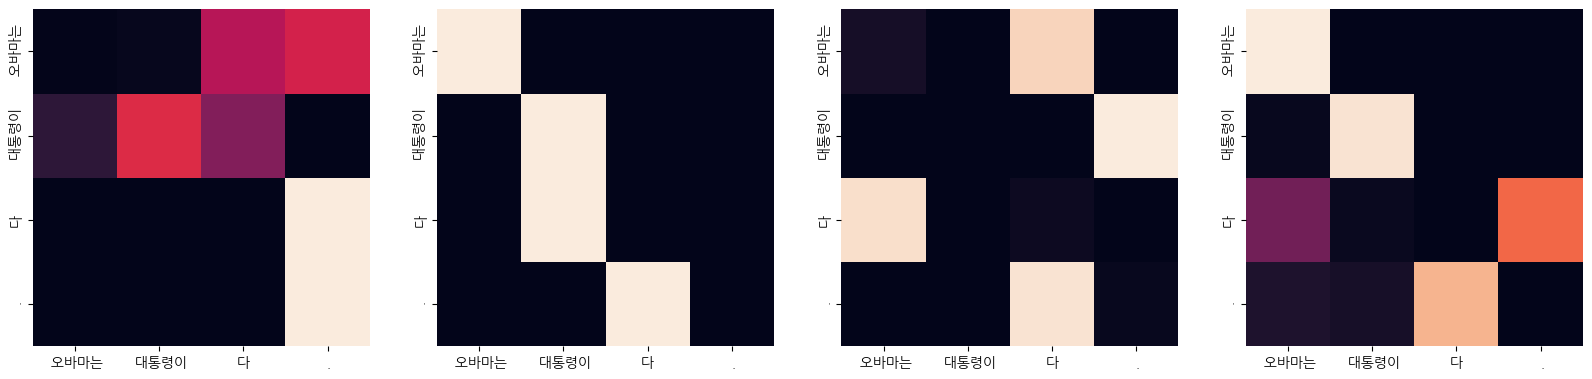

Encoder Layer 2


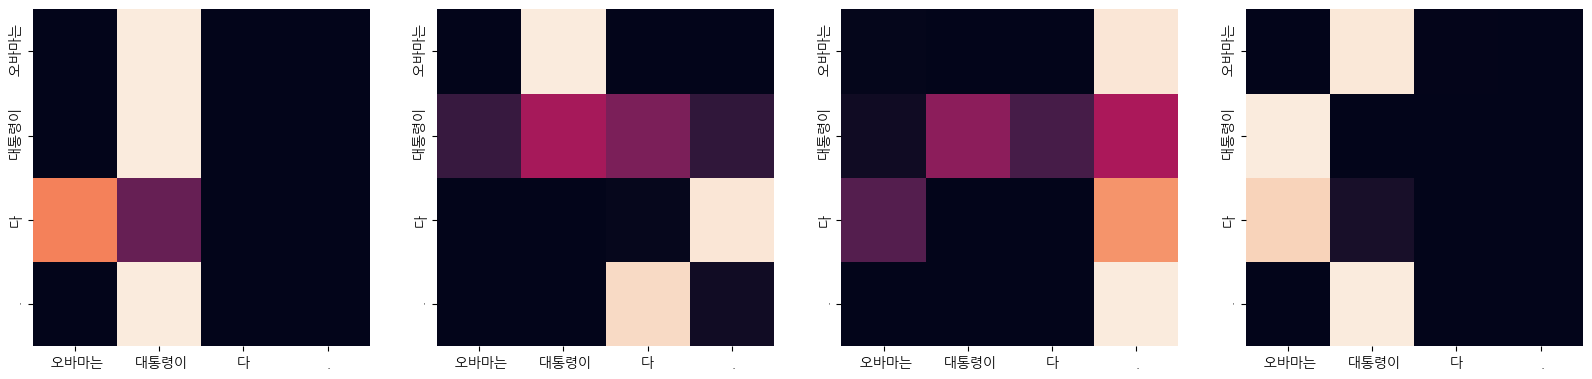

Decoder Self Layer 1


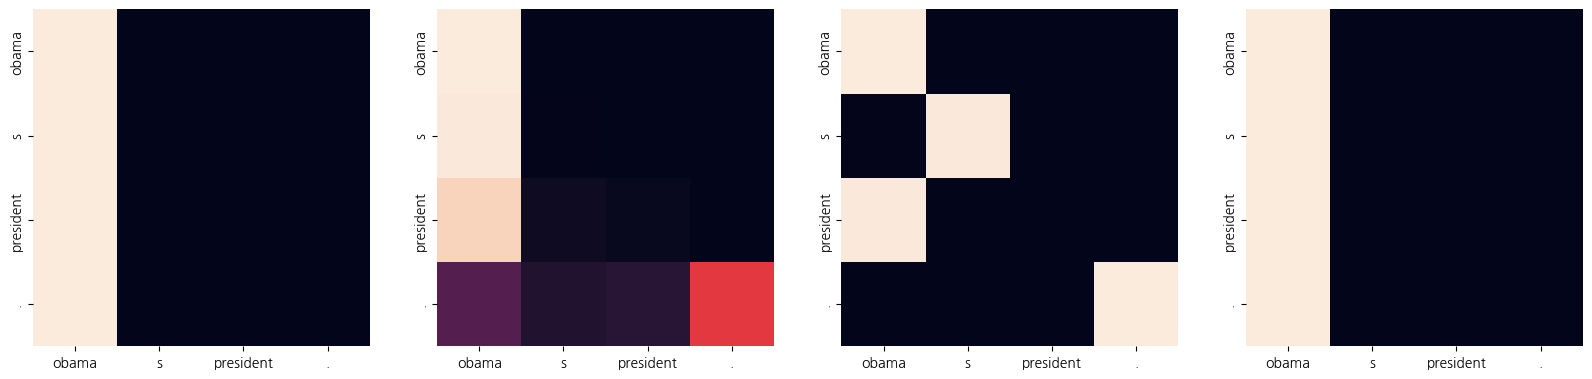

Decoder Src Layer 1


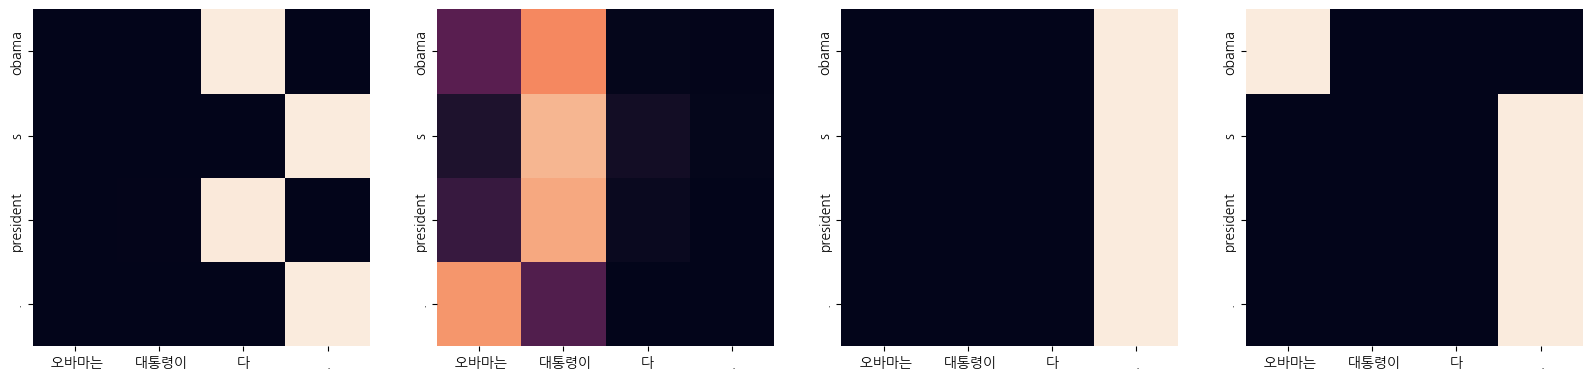

Decoder Self Layer 2


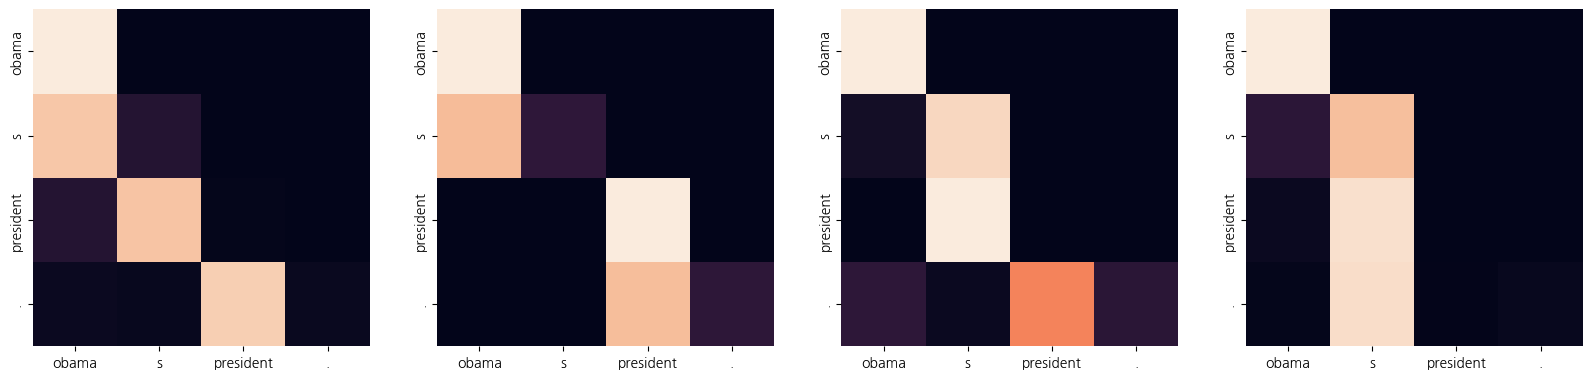

Decoder Src Layer 2


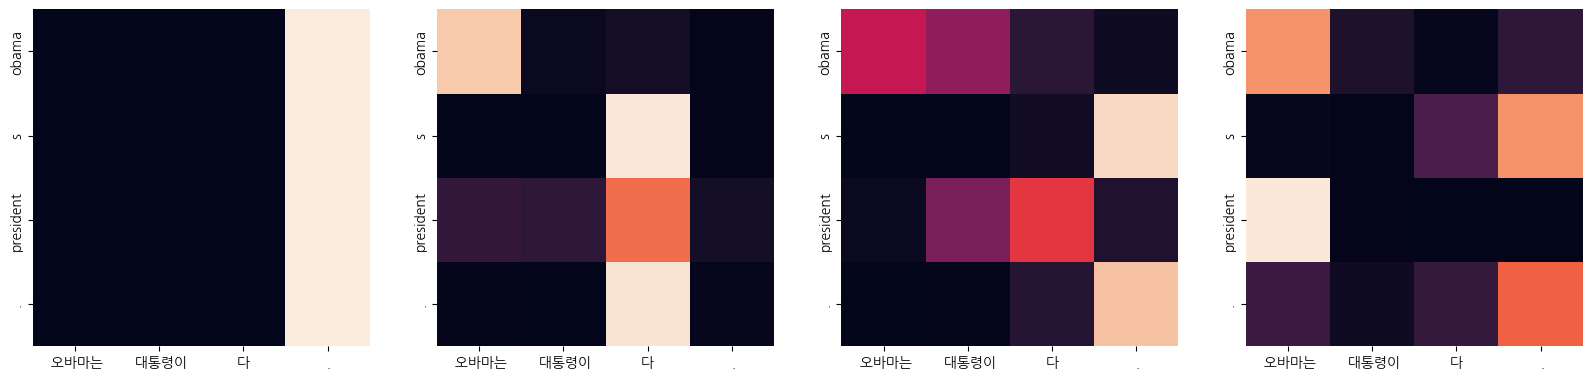

In [34]:
import matplotlib.pyplot as plt

translate("오바마는 대통령이다.", transformer, ko_tokenizer, en_tokenizer, plot_attention=True)

In [29]:
for s in EXAMPLE_SENTENCES:
    translate(s, transformer, ko_tokenizer, en_tokenizer, plot_attention=False)

Input: 오바마는 대통령이다.
Predicted translation: obama s president .
Input: 시민들은 도시 속에 산다.
Predicted translation: the city of the city s national cities .
Input: 커피는 필요 없다.
Predicted translation: .
Input: 임금 명의 사망자가 발생했다.
Predicted translation: at least people were killed in the dead .


## 회고

이번 프로젝트는 지금까지 했던 것들 중에 가장 "밑바닥부터" 만들어본 프로젝트였다. 저번 seq2seq 프로젝트에서는 LSTM 기반이라 어느 정도 익숙한 구조였는데, 이번엔 Multi-Head Attention부터 Positional Encoding, mask 세 종류(padding mask, causal mask, 그리고 둘을 합친 mask)까지 하나하나 손으로 짜다 보니 "논문을 읽는 것"과 "논문을 코드로 구현하는 것" 사이에 얼마나 큰 간극이 있는지 체감했다.

이번 프로젝트를 통해 "왜 실제 프로덕션 레벨의 번역/LLM 서비스들은 Transformer를 밑바닥부터 구현하지 않고 검증된 라이브러리(HuggingFace 등)를 쓰는지"를 몸으로 이해하게 됐다. 마스크 방향 하나, LayerNorm 위치 하나만 틀려도 학습 자체가 산으로 가버리는데, 이런 디테일들이 이미 다 검증되고 최적화되어 있는 라이브러리를 쓰는 게 왜 합리적인 선택인지 실감할 수 있었다. 다만 에이전트 엔지니어링 방향으로 가더라도, 이번처럼 내부 구조를 한 번 직접 만들어봐야 나중에 모델이 이상하게 동작할 때 "어디를 의심해봐야 하는지" 감을 잡을 수 있을 것 같다.